In [ ]:
# ============================================================
# EMAIL SPAM CLASSIFICATION SYSTEM
# Algorithms: KNN & Naïve Bayes
# Dataset: Spambase (UCI)
# ============================================================

In [ ]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)

import matplotlib.pyplot as plt
import seaborn as sns

# For better visuals
plt.rcParams["figure.figsize"] = (6,4)

print("Libraries imported successfully!\n")

Libraries imported successfully!



In [ ]:
# =========================
# 2. LOAD DATASET
# =========================
# Load directly from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data"
data = pd.read_csv(url, header=None)

print("Dataset loaded successfully!\n")

Dataset loaded successfully!



Dataset Shape: (4601, 58)

First 5 rows:
      0     1     2    3     4     5     6     7     8     9   ...    48  \
0  0.00  0.64  0.64  0.0  0.32  0.00  0.00  0.00  0.00  0.00  ...  0.00   
1  0.21  0.28  0.50  0.0  0.14  0.28  0.21  0.07  0.00  0.94  ...  0.00   
2  0.06  0.00  0.71  0.0  1.23  0.19  0.19  0.12  0.64  0.25  ...  0.01   
3  0.00  0.00  0.00  0.0  0.63  0.00  0.31  0.63  0.31  0.63  ...  0.00   
4  0.00  0.00  0.00  0.0  0.63  0.00  0.31  0.63  0.31  0.63  ...  0.00   

      49   50     51     52     53     54   55    56  57  
0  0.000  0.0  0.778  0.000  0.000  3.756   61   278   1  
1  0.132  0.0  0.372  0.180  0.048  5.114  101  1028   1  
2  0.143  0.0  0.276  0.184  0.010  9.821  485  2259   1  
3  0.137  0.0  0.137  0.000  0.000  3.537   40   191   1  
4  0.135  0.0  0.135  0.000  0.000  3.537   40   191   1  

[5 rows x 58 columns]

Missing Values:
 0

Class Distribution:
57
0    2788
1    1813
Name: count, dtype: int64


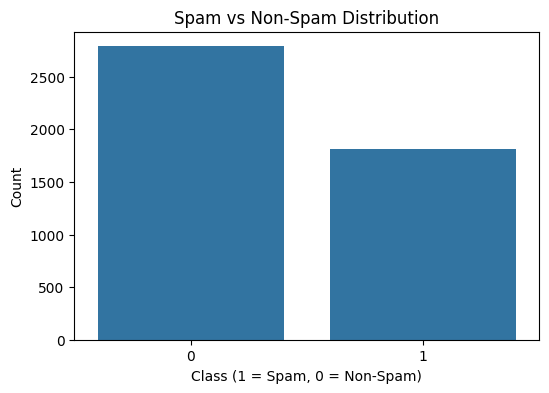

In [ ]:
# =========================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# =========================
print("Dataset Shape:", data.shape)
print("\nFirst 5 rows:\n", data.head())

print("\nMissing Values:\n", data.isnull().sum().sum())

print("\nClass Distribution:")
print(data.iloc[:, -1].value_counts())

# Plot class distribution
sns.countplot(x=data.iloc[:, -1])
plt.title("Spam vs Non-Spam Distribution")
plt.xlabel("Class (1 = Spam, 0 = Non-Spam)")
plt.ylabel("Count")
plt.show()

In [ ]:
# =========================
# 4. FEATURE & TARGET SPLIT
# =========================
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

print("\nFeatures and target separated.\n")


Features and target separated.



In [ ]:
# =========================
# 5. DATA NORMALIZATION
# =========================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data normalized using StandardScaler.\n")

Data normalized using StandardScaler.



In [ ]:
# =========================
# 6. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Data split into training and testing sets.\n")

Data split into training and testing sets.



In [ ]:
# =========================
# 7. KNN MODEL
# =========================
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Model Trained.\n")

KNN Model Trained.



In [ ]:
# =========================
# 8. NAÏVE BAYES MODEL
# =========================
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Naïve Bayes Model Trained.\n")


Naïve Bayes Model Trained.



In [ ]:
# =========================
# 9. EVALUATION FUNCTION
# =========================
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n===== {model_name} Performance =====")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


===== KNN Performance =====
Accuracy : 0.8957654723127035
Precision: 0.9016393442622951
Recall   : 0.8461538461538461
F1 Score : 0.873015873015873

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.93      0.91       531
           1       0.90      0.85      0.87       390

    accuracy                           0.90       921
   macro avg       0.90      0.89      0.89       921
weighted avg       0.90      0.90      0.90       921



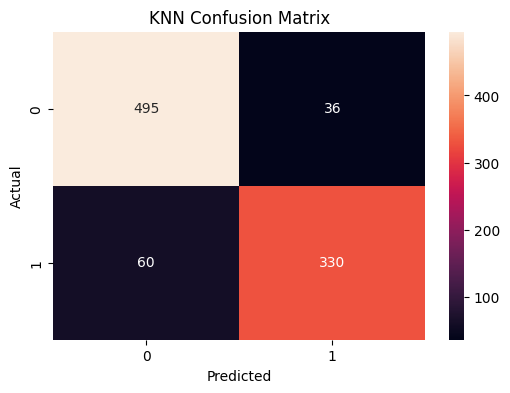


===== Naïve Bayes Performance =====
Accuracy : 0.8219326818675353
Precision: 0.7233201581027668
Recall   : 0.9384615384615385
F1 Score : 0.8169642857142857

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.74      0.83       531
           1       0.72      0.94      0.82       390

    accuracy                           0.82       921
   macro avg       0.83      0.84      0.82       921
weighted avg       0.85      0.82      0.82       921



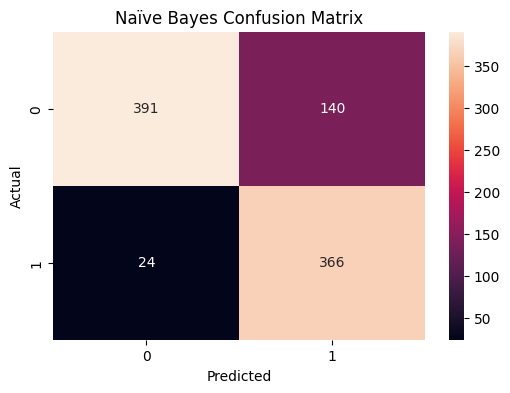

In [ ]:
# =========================
# 10. MODEL EVALUATION
# =========================
evaluate_model(y_test, y_pred_knn, "KNN")
evaluate_model(y_test, y_pred_nb, "Naïve Bayes")

In [ ]:
# =========================
# 11. MODEL COMPARISON
# =========================
comparison = pd.DataFrame({
    "Model": ["KNN", "Naïve Bayes"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_nb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_nb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_nb)
    ]
})

print("\n===== Model Comparison =====\n")
print(comparison)


===== Model Comparison =====

         Model  Accuracy  Precision    Recall  F1 Score
0          KNN  0.895765   0.901639  0.846154  0.873016
1  Naïve Bayes  0.821933   0.723320  0.938462  0.816964



===== KNN Optimization =====
K=1, Accuracy=0.8958
K=2, Accuracy=0.8838
K=3, Accuracy=0.8936
K=4, Accuracy=0.8860
K=5, Accuracy=0.8958
K=6, Accuracy=0.8903
K=7, Accuracy=0.8958
K=8, Accuracy=0.8936
K=9, Accuracy=0.8947
K=10, Accuracy=0.8947


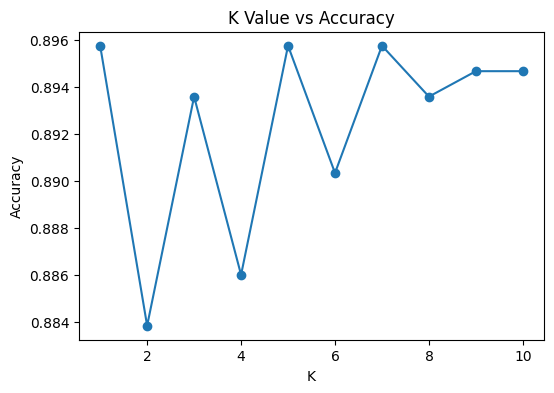

In [ ]:
# =========================
# 12. K VALUE OPTIMIZATION (BONUS)
# =========================
print("\n===== KNN Optimization =====")

k_values = range(1, 11)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"K={k}, Accuracy={acc:.4f}")

# Plot K vs Accuracy
plt.plot(k_values, accuracies, marker='o')
plt.title("K Value vs Accuracy")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
# =========================
# 13. FINAL CONCLUSION
# =========================
best_model = comparison.loc[comparison['Accuracy'].idxmax(), 'Model']

print("\n====================================")
print(f"Best Performing Model: {best_model}")
print("====================================")


Best Performing Model: KNN
